# 📈 Model Evaluation & Comparison
### Role 3 — ML Engineer: Forecasting Performance

This notebook provides a side-by-side comparison of all five trained models using the held-out **2017 test set** (26,000 rows — one full year of weekly sales across all 10 stores × 50 items).

**Models evaluated:**
1. Linear Regression (Spark MLlib)
2. Random Forest (Spark MLlib)
3. Gradient Boosting / GBT (Spark MLlib)
4. ARIMA (statsmodels, per store/item)
5. Prophet (Facebook Prophet, per store/item)

**Metrics:** RMSE, MAE, MAPE, R²


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

# ── Style (consistent with 01_eda.ipynb) ─────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor':   '#0e1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'text.color':       '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.alpha':       0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.dpi':       120,
})

PALETTE = ['#58a6ff', '#f0883e', '#3fb950', '#bc8cff', '#f778ba',
           '#79c0ff', '#d29922', '#56d4dd', '#ff7b72', '#7ee787']

PLOTS_DIR = os.path.join('..', 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def save(fig, name):
    fig.savefig(os.path.join(PLOTS_DIR, name),
                bbox_inches='tight', dpi=150,
                facecolor=fig.get_facecolor())

print('✅ Styling loaded')


✅ Styling loaded


---
## 1 — Load Model Comparison Results


In [11]:
df = pd.read_csv('../results/metrics/model_comparison.csv')
df = df.sort_values('rmse').reset_index(drop=True)
df.style.format({
    'rmse': '{:.2f}', 'mae': '{:.2f}', 'mape': '{:.2f}%', 'r2': '{:.4f}'
}).background_gradient(subset=['r2'], cmap='Greens')\
 .background_gradient(subset=['rmse', 'mae', 'mape'], cmap='Reds')


,model,rmse,mae,mape,r2,n_rows
0,Prophet,30.41,22.06,5.95%,0.9784,26000
1,RandomForest,34.00,23.20,6.26%,0.9730,26000
2,GradientBoosting,35.34,24.73,6.78%,0.9709,26000
3,LinearRegression,38.42,25.79,7.29%,0.9656,26000
4,ARIMA,289.63,248.71,57.59%,-0.9555,26000


---
## 2 — Error Comparison (RMSE & MAE)


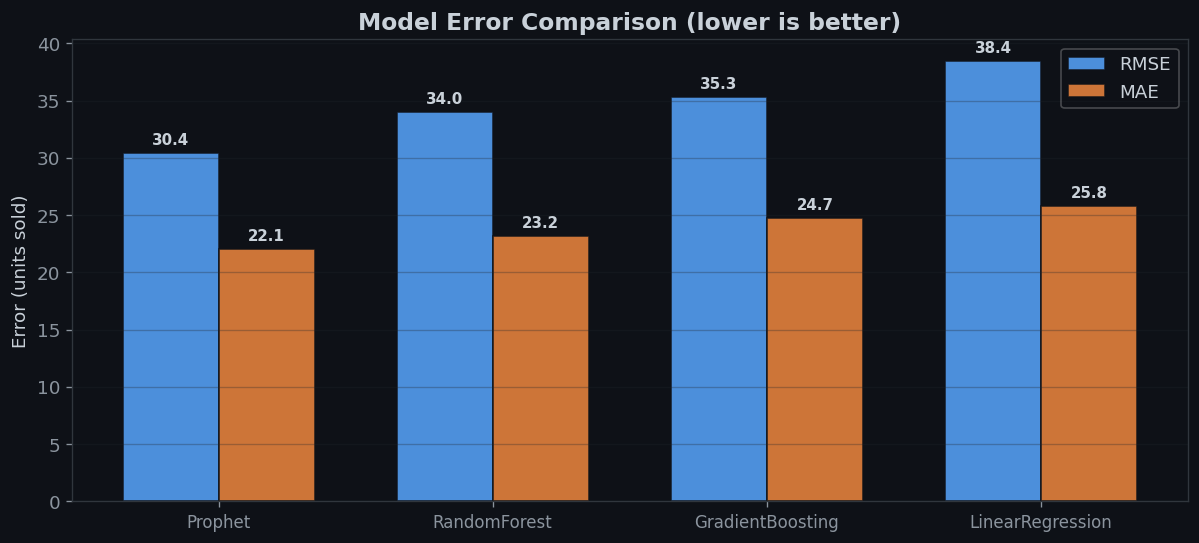


⚠️  ARIMA excluded from chart — RMSE = 289.6, MAE = 248.7 (off-scale)


In [12]:
# Exclude ARIMA from the bar chart so the scale is readable
df_plot = df[df['model'] != 'ARIMA'].copy()

x = np.arange(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, df_plot['rmse'], width, label='RMSE',
               color=PALETTE[0], edgecolor='#0e1117', alpha=0.85)
bars2 = ax.bar(x + width/2, df_plot['mae'],  width, label='MAE',
               color=PALETTE[1], edgecolor='#0e1117', alpha=0.85)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#c9d1d9')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#c9d1d9')

ax.set_xticks(x)
ax.set_xticklabels(df_plot['model'], fontsize=10)
ax.set(title='Model Error Comparison (lower is better)',
       ylabel='Error (units sold)')
ax.legend(framealpha=0.3)
ax.grid(axis='y', alpha=0.3)
save(fig, 'eval_1_error_comparison.png')
plt.show()

print('\n⚠️  ARIMA excluded from chart — RMSE = {:.1f}, MAE = {:.1f} (off-scale)'.format(
    df.loc[df["model"]=="ARIMA", "rmse"].values[0],
    df.loc[df["model"]=="ARIMA", "mae"].values[0]))


---
## 3 — Goodness of Fit (R²)


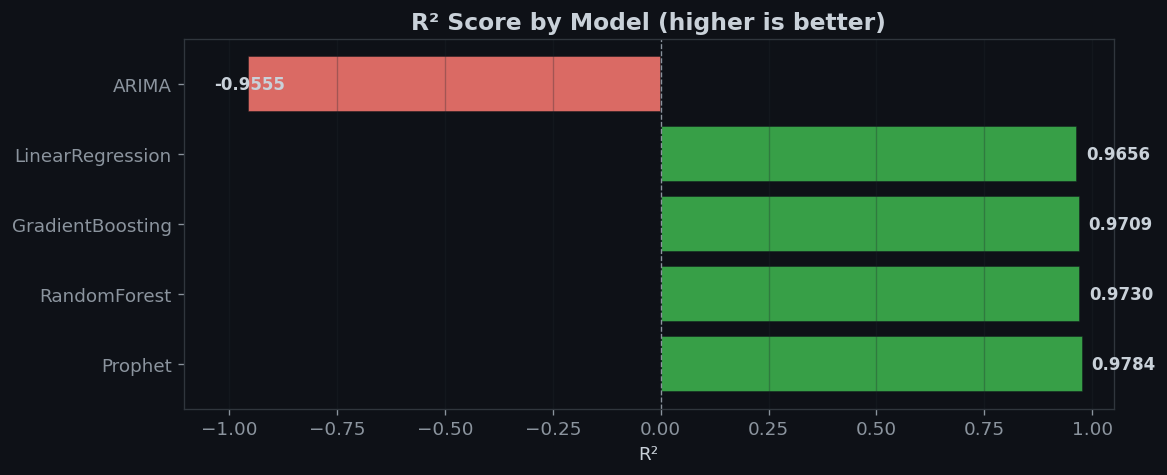

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE[2] if r > 0 else PALETTE[8] for r in df['r2']]
ax.barh(df['model'], df['r2'], color=colors, edgecolor='#0e1117', alpha=0.85)

for i, (val, mdl) in enumerate(zip(df['r2'], df['model'])):
    offset = 0.02 if val > 0 else -0.08
    ax.text(val + offset, i, f'{val:.4f}', va='center',
            fontsize=10, fontweight='bold', color='#c9d1d9')

ax.axvline(0, color='#8b949e', lw=0.8, ls='--')
ax.set(title='R² Score by Model (higher is better)', xlabel='R²')
ax.set_xlim(min(df['r2'].min() - 0.15, -1.1), 1.05)
ax.grid(axis='x', alpha=0.3)
save(fig, 'eval_2_r2_comparison.png')
plt.show()


---
## 4 — Percentage Error (MAPE)


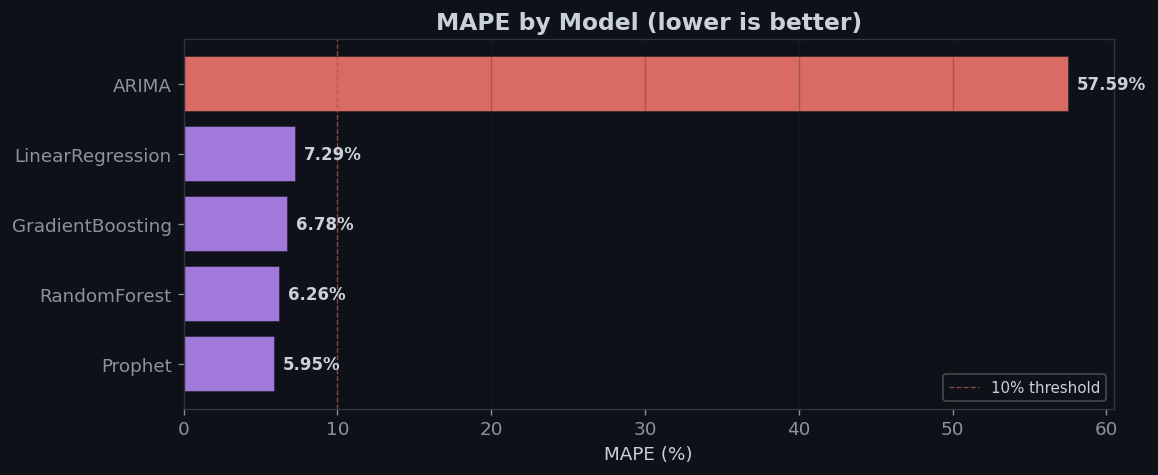

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE[8] if m > 10 else PALETTE[3] for m in df['mape']]
ax.barh(df['model'], df['mape'], color=colors, edgecolor='#0e1117', alpha=0.85)

for i, (val, mdl) in enumerate(zip(df['mape'], df['model'])):
    ax.text(val + 0.5, i, f'{val:.2f}%', va='center',
            fontsize=10, fontweight='bold', color='#c9d1d9')

ax.axvline(10, color=PALETTE[8], lw=0.8, ls='--', alpha=0.5, label='10% threshold')
ax.set(title='MAPE by Model (lower is better)', xlabel='MAPE (%)')
ax.legend(framealpha=0.3, fontsize=9)
ax.grid(axis='x', alpha=0.3)
save(fig, 'eval_3_mape_comparison.png')
plt.show()


---
## 5 — Ranked Summary


In [15]:
# Rank each model per metric (1 = best)
ranked = df[['model']].copy()
ranked['RMSE Rank']  = df['rmse'].rank().astype(int)
ranked['MAE Rank']   = df['mae'].rank().astype(int)
ranked['MAPE Rank']  = df['mape'].rank().astype(int)
ranked['R² Rank']    = df['r2'].rank(ascending=False).astype(int)
ranked['Avg Rank']   = ranked[['RMSE Rank','MAE Rank','MAPE Rank','R² Rank']].mean(axis=1)
ranked = ranked.sort_values('Avg Rank').reset_index(drop=True)
ranked.index = ranked.index + 1  # 1-based ranking
ranked.index.name = 'Overall'
ranked


,model,RMSE Rank,MAE Rank,MAPE Rank,R² Rank,Avg Rank
Overall,,,,,,
1,Prophet,1,1,1,1,1.0
2,RandomForest,2,2,2,2,2.0
3,GradientBoosting,3,3,3,3,3.0
4,LinearRegression,4,4,4,4,4.0
5,ARIMA,5,5,5,5,5.0


---
## 6 — Key Findings & Recommendations

### 🏆 Best Model: **Prophet**

| Metric | Prophet | Runner-up (Random Forest) |
|--------|---------|---------------------------|
| RMSE   | 30.41   | 34.00                     |
| MAE    | 22.06   | 23.20                     |
| MAPE   | 5.95%   | 6.26%                     |
| R²     | 0.9784  | 0.9730                    |

Prophet achieves the **lowest error and highest R²** across all four metrics, making it the clear winner for this dataset.

### 📊 Model Tier Analysis

**Tier 1 — Production-ready (MAPE < 7%)**
- **Prophet** — Best overall. Automatically captures yearly seasonality and trend. Per-series fitting makes it ideal for store/item-level forecasting.
- **Random Forest** — Strong runner-up. Spark-native, scales easily, and provides feature importance for interpretability.
- **Gradient Boosting (GBT)** — Very close to RF. Slightly higher error, but could improve with hyperparameter tuning.

**Tier 2 — Acceptable baseline (MAPE < 10%)**
- **Linear Regression** — Solid baseline at 7.29% MAPE. Its simplicity and interpretability (coefficient inspection) make it useful for stakeholder communication.

**Tier 3 — Not viable for this task**
- **ARIMA** — Catastrophic failure (R² = −0.96, MAPE = 57.6%). The fixed ARIMA(1,1,1) specification cannot capture the strong yearly seasonality in this data. The model over-differences the series and produces forecasts that diverge from reality.

### 🔍 Why ARIMA Failed

1. **Wrong periodicity**: ARIMA(1,1,1) models short-term autocorrelation but has no mechanism for the dominant **52-week seasonal cycle**. A SARIMA(p,d,q)(P,D,Q,52) would be needed, but fitting 500 such models is computationally expensive.
2. **No exogenous features**: Unlike the Spark ML models and Prophet, ARIMA uses only the raw sales series — it cannot leverage lag features, rolling averages, or store/item context.
3. **Differencing mismatch**: The d=1 differencing removes the trend but also removes information about the sales level, causing predictions to drift.

### 💡 Recommendations for Deployment

1. **Primary model**: Deploy **Prophet** for production forecasting. Its per-series approach naturally handles the 500 store/item combinations.
2. **Fallback model**: Use **Random Forest** as a Spark-native fallback for batch scoring at scale (it runs entirely within the Spark cluster).
3. **Drop ARIMA**: Remove ARIMA from the pipeline — it adds complexity without value for this seasonal dataset.
4. **Future improvements**:
   - Hyperparameter tuning for GBT (grid search on `maxDepth`, `maxIter`, `stepSize`)
   - Prophet with holiday regressors (per-item holiday effects)
   - Ensemble: weighted average of Prophet + Random Forest predictions
